In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### FUNCTIONS ###

def generate_points(mean=[0., 0.], angle_deg=45, lamb=np.array([[100, 0], [0, 1]]), n=100, seed=None):
    """
    Generate random 2D points with covariance structure defined by rotation and lambda matrix.
    """
    if seed is not None:
        np.random.seed(seed)

    angle = angle_deg * math.pi / 180
    rot = np.array([[math.cos(angle), -math.sin(angle)], 
                    [math.sin(angle),  math.cos(angle)]])
    s = np.matmul(rot, np.matmul(lamb, rot.T))
    points = np.random.multivariate_normal(mean, s, n)
    return points


def plot_regression(points, w, outliers=None, title="Linear Regression Fit"):
    """
    Plot dataset and regression line.
    points: Nx2 array of [x, y]
    w: tuple/list (w0, w1)
    outliers: list of indices to highlight
    """
    x = points[:, 0]
    y = points[:, 1]
    y_pred = w[0] * x + w[1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, label='Data points', color='blue', alpha=0.7)

    # Highlight outliers if any
    if outliers is not None:
        plt.scatter(x[outliers], y[outliers], color='red', label='Outliers', s=80, marker='x')

    plt.plot(x, y_pred, color='orange', linewidth=2, label='Fitted line')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


def gradient_descent(points, rho=lambda u: 0.5 * u**2, rho_prime=lambda u: u, 
                     alpha=1e-4, max_iter=10000, tol=1e-6):
    """
    Perform gradient descent to find w0, w1 minimizing sum of rho(e_i)
    where e_i = w0*x_i + w1 - y_i.
    
    - rho: error function
    - rho_prime: derivative of rho
    - alpha: learning rate
    - tol: stopping threshold for gradient norm
    """
    x = points[:, 0]
    y = points[:, 1]

    # Initialize parameters
    w0, w1 = 0.0, 0.0

    for i in range(max_iter):
        y_pred = w0 * x + w1
        e = y_pred - y

        # Compute gradients
        grad_w0 = np.sum(rho_prime(e) * x)
        grad_w1 = np.sum(rho_prime(e))

        grad_norm = np.sqrt(grad_w0**2 + grad_w1**2)
        if grad_norm < tol:
            break

        # Update parameters
        w0 -= alpha * grad_w0
        w1 -= alpha * grad_w1

    return w0, w1

def gradient_descent_robust(points, c=1, alpha=1e-4, max_iter=10000, tol=1e-6):
    """
    Perform gradient descent using the Cauchy robust error function:
    rho(u) = (c^2 / 2) * log(1 + (u / c)^2)
    rho'(u) = u / (1 + (u / c)^2)
    """
    rho = lambda u: 0.5 * (c**2) * np.log(1 + (u / c)**2)
    rho_prime = lambda u: u / (1 + (u / c)**2)
    return gradient_descent(points, rho=rho, rho_prime=rho_prime,
                            alpha=alpha, max_iter=max_iter, tol=tol)

def compare_regression_methods(points, c=1, title_suffix="(no outliers)"):
    """
    Compare Least Squares vs Cauchy Robust regression on the same dataset.
    Fits both models, prints parameters, and plots results.
    """
    # Fit both models
    w_ls = gradient_descent(points)
    w_cauchy = gradient_descent_robust(points, c=c)

    # Print parameters
    print(f"=== Regression Comparison {title_suffix} ===")
    print(f"Least Squares Fit: w0 = {w_ls[0]:.4f}, w1 = {w_ls[1]:.4f}")
    print(f"Cauchy Robust Fit (c={c}): w0 = {w_cauchy[0]:.4f}, w1 = {w_cauchy[1]:.4f}")

    # Plot comparison
    x = points[:, 0]
    y = points[:, 1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')

    # Compute predicted lines
    y_ls = w_ls[0] * x + w_ls[1]
    y_cauchy = w_cauchy[0] * x + w_cauchy[1]

    # Plot both
    plt.plot(x, y_ls, color='orange', linewidth=2, label='Least Squares Fit')
    plt.plot(x, y_cauchy, color='green', linewidth=2, linestyle='--', label=f'Cauchy Robust Fit (c={c})')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Linear Regression Comparison {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.show()

    return w_ls, w_cauchy


Least Squares Fit Parameters:
w0 (slope): 0.9659664355531029
w1 (intercept): 0.07510702192147199


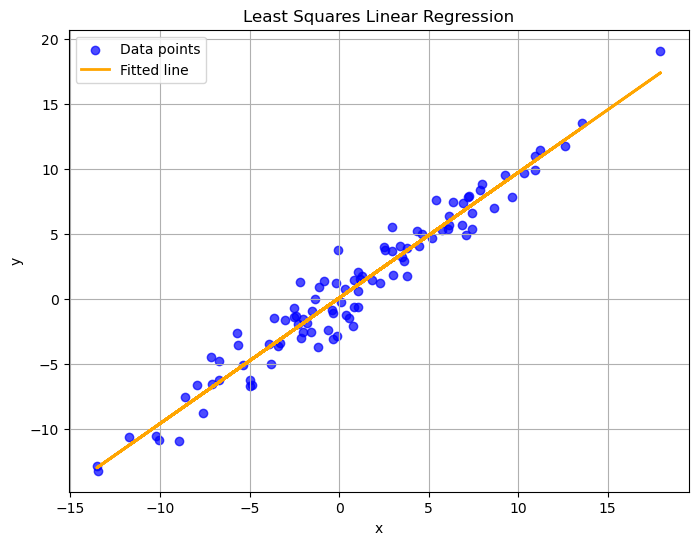

In [2]:
# Generate points
points = generate_points(angle_deg=45, seed=42)

# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

print("Least Squares Fit Parameters:")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression")

Least Squares Fit Parameters:
w0 (slope): 0.5222779250220864
w1 (intercept): 0.8541772108284581


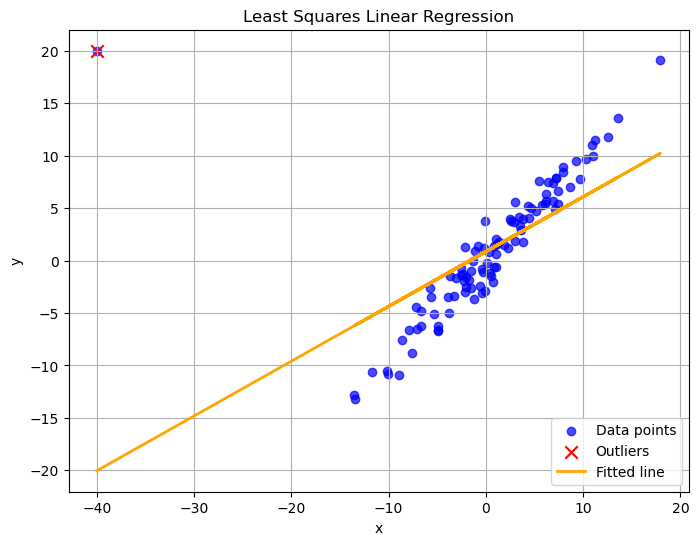

In [3]:
out_idx = 0
points[out_idx] = [-40, 20]
outliers = [out_idx]

# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

print("Least Squares Fit Parameters:")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression", outliers=outliers)

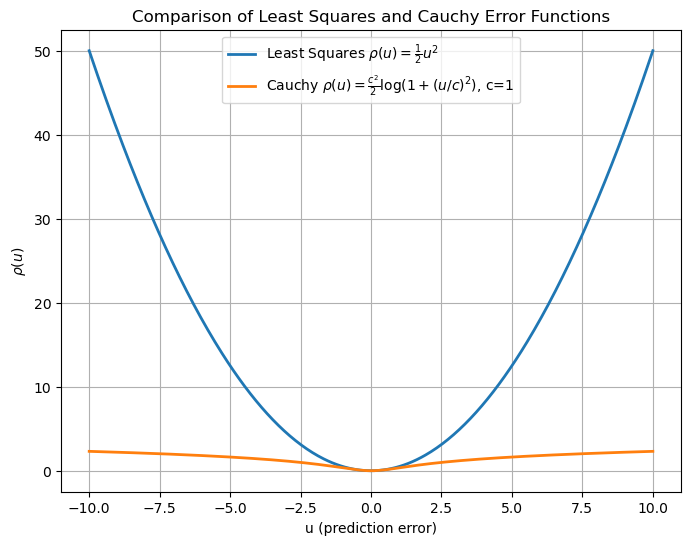

In [4]:
# Compare Least Squares vs Cauchy function
u = np.linspace(-10, 10, 400)
rho_ls = 0.5 * u**2
c = 1
rho_cauchy = 0.5 * (c**2) * np.log(1 + (u / c)**2)

plt.figure(figsize=(8, 6))
plt.plot(u, rho_ls, label=r'Least Squares $\rho(u) = \frac{1}{2}u^2$', linewidth=2)
plt.plot(u, rho_cauchy, label=r'Cauchy $\rho(u) = \frac{c^2}{2}\log(1+(u/c)^2)$, c=1', linewidth=2)
plt.xlabel('u (prediction error)')
plt.ylabel(r'$\rho(u)$')
plt.title('Comparison of Least Squares and Cauchy Error Functions')
plt.legend()
plt.grid(True)
plt.show()

=== Regression Comparison (clean dataset) ===
Least Squares Fit: w0 = 0.9851, w1 = 0.2005
Cauchy Robust Fit (c=1): w0 = 0.9856, w1 = 0.2519


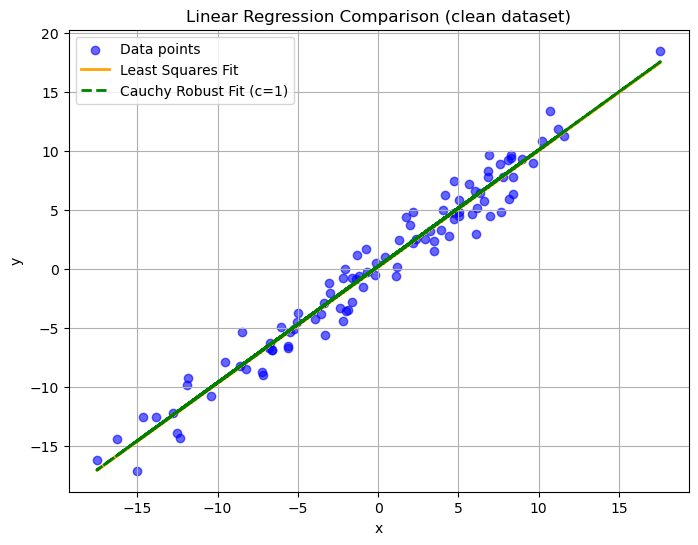

In [5]:
# Generate new clean dataset
points = generate_points(angle_deg=45, seed=0)


# Compare Least Squares and Cauchy Robust regression
w_ls, w_cauchy = compare_regression_methods(points, c=1, title_suffix="(clean dataset)")

=== Regression Comparison (clean dataset) ===
Least Squares Fit: w0 = 0.6338, w1 = 0.6620
Cauchy Robust Fit (c=1): w0 = 0.9873, w1 = 0.2453


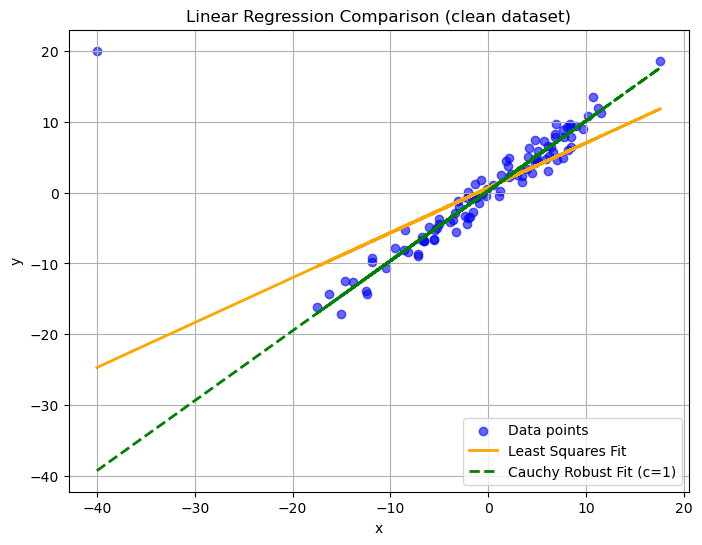

In [6]:
# Generate new clean dataset and perturbate it
points = generate_points(angle_deg=45, seed=0)
out_idx = 0
points[out_idx] = [-40, 20]
outliers = [out_idx]

# Compare Least Squares and Cauchy Robust regression
w_ls, w_cauchy = compare_regression_methods(points, c=1, title_suffix="(clean dataset)")